# Good pipeline is working just see how you can hyper parameter tune and why is in summary table only 1 model is visible

### Need to start learning RAG ,Learn about Json Schema , done till the scaling for linear models now start model building remember to write the resons and why am i using diffrent steps for linear and other models

In [1]:
#!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline          
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("D:\churnsense\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **EDA**

In [5]:
print(f"Shape:{df.shape}") 

Shape:(7043, 21)


In [6]:
print(f"Data types:\n{df.dtypes}")

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [7]:
print(f"Null values:\n{df.isnull().sum()}")

Null values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
print(f"Duplicates:{df.duplicated().sum()}")

Duplicates:0


In [9]:
with pd.option_context('display.max_columns', None):
    display(df.head())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### **Total Charges should be a numeric column so changing this column to Numeric Dtype**

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors='coerce')   # "errors='coerce'"what it does is if the value has a parsing error or not of the same format so instead of getting a error, it replaces it with Null Values while conversion

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

- **TotalCharges when it was an object had null values but due to space, it did not show any null values. But when we changed it to numeric using 'errors = coerce' so it made it null**

In [12]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
df[df['TotalCharges'].isnull()][['tenure',"TotalCharges"]]

,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


#### **From here we can see that 'TotalCharges' is null when the 'tenure' is 0. Which shows the customer is new and hasn't completed billing cycle**

- **To fill null values, we will replace null with 0 as the "Total charges" $\approx\$ (tenure * monthly), here we cannot use mean or median  as it would be inaccurate.**

In [14]:
# Filling null values with the median as the variable is skewed
df["TotalCharges"].fillna(0,inplace=True)

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### - **% of Churned customers**

In [16]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

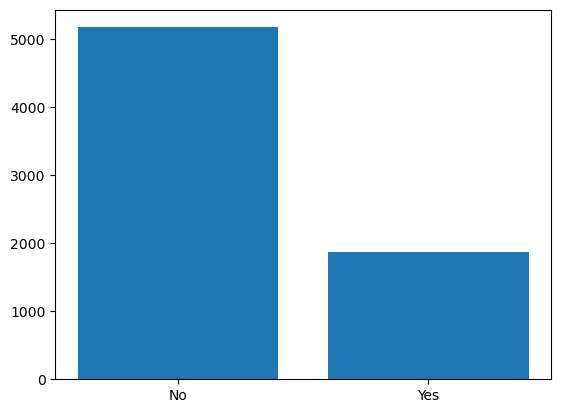

In [17]:
plt.bar(df["Churn"].value_counts().index,df["Churn"].value_counts())
plt.show

In [18]:
print(f"Churn % :{(((df["Churn"].value_counts()[1:2])/df.shape[0])*100).iloc[0]}")

Churn % :26.536987079369588


- **From here, we can see the dataset is imbalanced, with only 26% of churn records**

In [19]:
col = list(df.columns)

In [20]:
for i in col:
    if df[i].dtype == object and i != 'customerID':
        print(f"{df.groupby(i)['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending = False)}\n")
    

gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64

Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64

Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64

PhoneService
Yes    26.709637
No     24.926686
Name: Churn, dtype: float64

MultipleLines
Yes                 28.609896
No                  25.044248
No phone service    24.926686
Name: Churn, dtype: float64

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64

OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Churn, dtype: float64

DeviceProtection
No                     39.127625
Yes                    22.502064
No internet service     7.404980
Name: Churn, dtype: float64

TechSupport
No       

In [21]:
num_cols = df.select_dtypes(include = ['int','float']).columns.to_list()

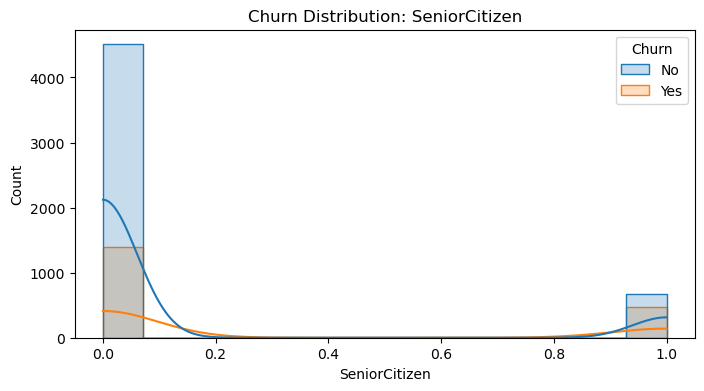

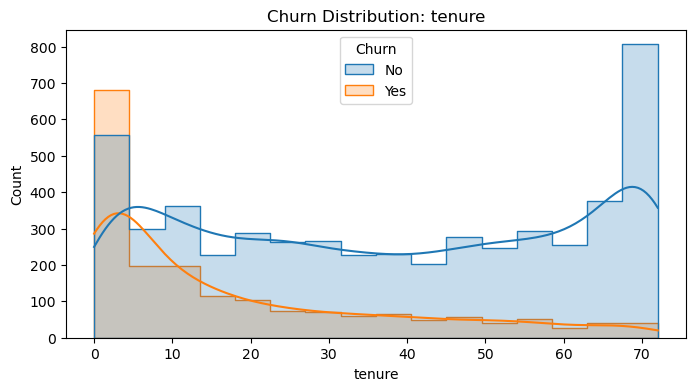

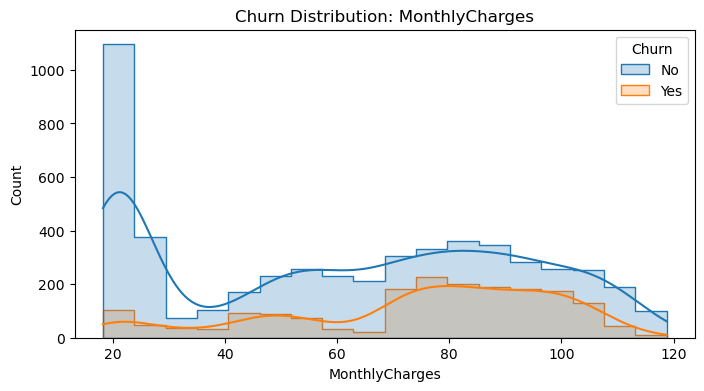

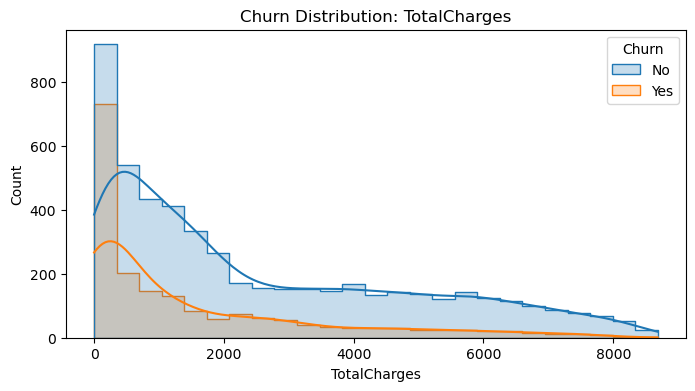

In [22]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step")
    plt.title(f'Churn Distribution: {col}')
    plt.show()

In [23]:
df.select_dtypes(include=['int','float']).corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


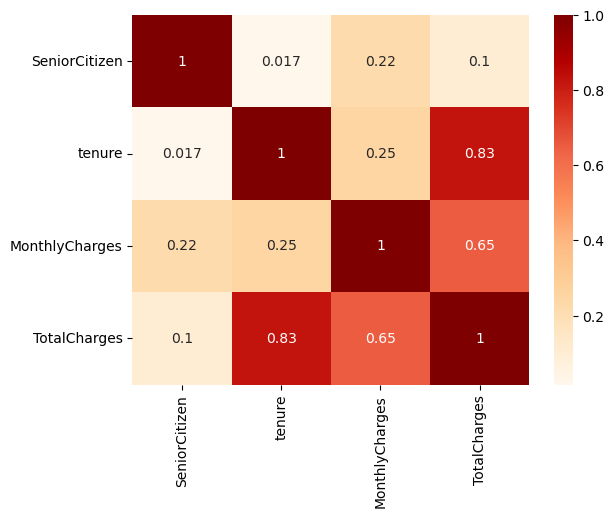

In [24]:
sns.heatmap(data = df.select_dtypes(include=['int','float']).corr(),annot=True,cmap="OrRd")
plt.show()

In [25]:
df_f = df.copy()

In [26]:

# Define your boundary bins and the numeric labels you want to assign
bins = [0, 12, 24, 36, 48, 60, 72, 84, float('inf')]
labels = [1, 2, 3, 4, 5, 6, 7, 8]

# Create a new column with the grouped values
df_f['tenure_group'] = pd.cut(df_f['tenure'], bins=bins, labels=labels, include_lowest=True)


In [27]:
df_f['tenure_group'].unique()

[1, 3, 4, 2, 6, 5]
Categories (8, int64): [1 < 2 < 3 < 4 < 5 < 6 < 7 < 8]

**Preprocessing**

In [28]:
# Encoding Target Variable
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

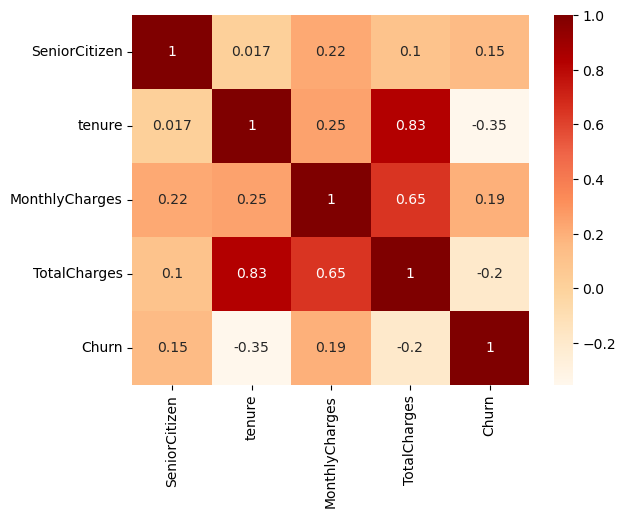

In [29]:
sns.heatmap(data = df.select_dtypes(include=['int','float']).corr(),annot=True,cmap="OrRd")
plt.show()

In [30]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

**Skewness and treating it**

In [31]:
df.select_dtypes(include = "number").skew().sort_values(ascending = False)

SeniorCitizen     1.833633
Churn             1.063031
TotalCharges      0.963235
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64

In [32]:
pt = PowerTransformer(method='yeo-johnson')

df['TotalCharges'] = pt.fit_transform(df[['TotalCharges']])

In [33]:
print(f"New skewness for Totalcharges: {df['TotalCharges'].skew()}")

New skewness for Totalcharges: -0.1461205173267185


- **Splitting the dataset into X and Y(target variable)**

In [34]:
x = df.drop(columns = "Churn")
y = df["Churn"]

In [35]:
# Dropping customerId as it has no predictive use
x.drop(columns = "customerID",inplace=True)


In [36]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [37]:
numeric_cols = x.select_dtypes(include = 'number').drop(columns = 'TotalCharges').columns.to_list()
numeric_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [38]:
categorical_cols = x.select_dtypes(include = 'object').drop(columns = 'Contract').columns.to_list()
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'PaymentMethod']

In [39]:
ordinal_cat_col = x[['Contract']].columns.to_list()
ordinal_cat_col

['Contract']

- **Train-Test Split**

In [40]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

In [41]:
preprocessor = ColumnTransformer([
    ('num',    StandardScaler(),  numeric_cols),
    ('cat',    OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('ordinal_cat',    OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cat_col)
], remainder='drop')

In [42]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'PaperlessBilling',
                                  'PaymentMethod']),
                                ('ordinal_cat',
                                 OrdinalEncoder(categories=[['Month-to-month',
                                                             'One year',
                                                             'Two year']],
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['Contract'])])

# train test split first then use column transformer  and further pipleine

In [43]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),   # ← applied after preprocessing
    ('model',        RandomForestClassifier(    #    only during fit(), never
                         n_estimators=100,      #    during predict()
                         random_state=42,
                         class_weight='balanced'))
])

In [44]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('ordinal_cat',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Contract'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [45]:
y_pred = pipeline.predict(X_test)


In [46]:
print(classification_report(y_test, y_pred,
                             target_names=['Not Churned', 'Churned']))

              precision    recall  f1-score   support

 Not Churned       0.84      0.87      0.86      1294
     Churned       0.60      0.55      0.58       467

    accuracy                           0.79      1761
   macro avg       0.72      0.71      0.72      1761
weighted avg       0.78      0.79      0.78      1761



In [47]:
print("ROC-AUC:", roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1]))


ROC-AUC: 0.8196907817004193


In [48]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000,
                                                class_weight='balanced'),
    'Decision Tree'        : DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100,
                                                    class_weight='balanced',
                                                    random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100,
                                                        random_state=42),
    'XGBoost'              : XGBClassifier(n_estimators=100,
                                           scale_pos_weight=3,  # handles imbalance
                                           random_state=42,
                                           eval_metric='logloss')
}


  Logistic Regression
              precision    recall  f1-score   support

 Not Churned       0.90      0.74      0.81      1294
     Churned       0.52      0.77      0.62       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.76      1761

ROC-AUC: 0.8415


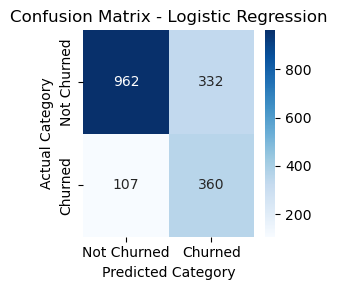


  Decision Tree
              precision    recall  f1-score   support

 Not Churned       0.83      0.79      0.81      1294
     Churned       0.48      0.54      0.51       467

    accuracy                           0.72      1761
   macro avg       0.65      0.66      0.66      1761
weighted avg       0.73      0.72      0.73      1761

ROC-AUC: 0.6642


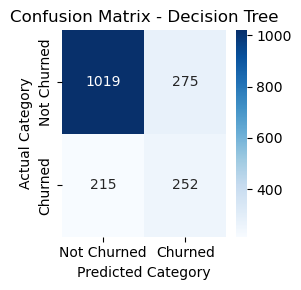


  Random Forest
              precision    recall  f1-score   support

 Not Churned       0.84      0.87      0.86      1294
     Churned       0.60      0.55      0.58       467

    accuracy                           0.79      1761
   macro avg       0.72      0.71      0.72      1761
weighted avg       0.78      0.79      0.78      1761

ROC-AUC: 0.8197


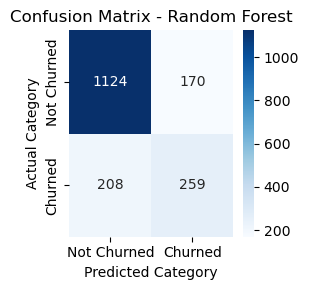


  Gradient Boosting
              precision    recall  f1-score   support

 Not Churned       0.88      0.82      0.85      1294
     Churned       0.57      0.68      0.62       467

    accuracy                           0.78      1761
   macro avg       0.72      0.75      0.73      1761
weighted avg       0.80      0.78      0.79      1761

ROC-AUC: 0.8419


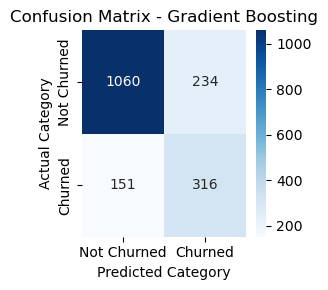


  XGBoost
              precision    recall  f1-score   support

 Not Churned       0.87      0.76      0.81      1294
     Churned       0.51      0.70      0.59       467

    accuracy                           0.74      1761
   macro avg       0.69      0.73      0.70      1761
weighted avg       0.78      0.74      0.75      1761

ROC-AUC: 0.8104


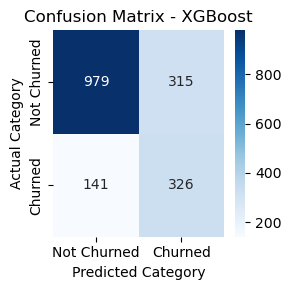

In [58]:
results = {}   # store results for comparison later

for name, model in models.items():
    # Build pipeline with same preprocessor, different model
    pipe = Pipeline([
        ('preprocessor', preprocessor),      # ← same preprocessor reused
        ('smote',        SMOTE(random_state=42)),
        ('model',        model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_pred_prob = pipe.predict_proba(X_test)[:,1]

    roc_auc  = roc_auc_score(y_test, y_pred_prob)

    
    results[name] = {
        'pipeline'  : pipe,
        'roc_auc'   : roc_auc,
        'y_pred'    : y_pred
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['Not Churned', 'Churned']))
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    

    plt.figure(figsize=(3, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Churned', 'Churned'], 
                yticklabels=['Not Churned', 'Churned'])
    
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.tight_layout()
    plt.show() 

In [53]:
comparison = []
for name, result in results.items():
    y_pred = result['y_pred']
    comparison.append({
        'Model'          : name,
        'ROC-AUC'        : round(result['roc_auc'], 4),
        'Churn Recall'   : round(recall_score(y_test, y_pred, pos_label=1), 4),
        'Churn Precision': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Churn F1'       : round(f1_score(y_test, y_pred, pos_label=1), 4),
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print(comparison_df.to_string(index=False))

              Model  ROC-AUC  Churn Recall  Churn Precision  Churn F1
  Gradient Boosting   0.8419        0.6767           0.5745    0.6214
Logistic Regression   0.8415        0.7709           0.5202    0.6212
      Random Forest   0.8197        0.5546           0.6037    0.5781
            XGBoost   0.8104        0.6981           0.5086    0.5884
      Decision Tree   0.6642        0.5396           0.4782    0.5070


In [28]:
df.select_dtypes(include ='object').columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [39]:
#df_cop = df.copy()

In [40]:
#la_1 = LabelEncoder()

# 3. Identify categorical columns
#cat_cols = df_cop.select_dtypes(include=['object']).columns

# 4. Apply Label Encoding to each column
#for col in cat_cols:
  #  df_cop[col] = la_1.fit_transform(df_cop[col])

In [41]:
#df_cop.shape

In [37]:
#df_cop.select_dtypes(include=['int','float']).corr()

In [42]:
#plt.figure(figsize=(18,8))
#sns.heatmap(data = df_cop.select_dtypes(include=['int','float']).corr(),annot=True,cmap="OrRd")
#plt.show()

In [34]:
df_cop["PaperlessBilling"].unique()

array([1, 0])

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.select_dtypes(include = 'number').skew().sort_values(ascending = False)

SeniorCitizen     1.833633
Churn             1.063031
TotalCharges      0.963789
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64

In [38]:
x = df.drop(columns = "Churn")
y = df["Churn"]


In [39]:
X = x.copy()

#### For linear algos

In [40]:
x_linr = x.copy()

In [41]:
x_linr.select_dtypes(include = 'number').skew().sort_values(ascending = False)

SeniorCitizen     1.833633
TotalCharges      0.963789
tenure            0.239540
MonthlyCharges   -0.220524
dtype: float64

- **Skewness Treatment**

In [42]:
# "TotalCharges Skewness Treatment"
from sklearn.preprocessing import PowerTransformer

In [43]:
pt = PowerTransformer(method='yeo-johnson')

In [44]:
x_linr['TotalCharges'] = pt.fit_transform(x_linr[['TotalCharges']])

In [45]:
print(f"New skewness for Totalcharges: {x_linr['TotalCharges'].skew()}")

New skewness for Totalcharges: -0.14433732998312213


In [46]:
df["SeniorCitizen"].unique()

array([0, 1])

In [47]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [49]:
x_linr.drop(columns = 'customerID',inplace=True)

In [50]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a copy of your features
#x_label = x.copy()

# 2. Initialize the LabelEncoder
le_1 = LabelEncoder()

# 3. Identify categorical columns
categorical_cols = x_linr.select_dtypes(include=['object']).columns

# 4. Apply Label Encoding to each column
for col in categorical_cols:
    x_linr[col] = le_1.fit_transform(x_linr[col])

# Check the results
#x_label.head()

In [51]:
X_train_li, X_test_li, y_train_li, y_test_li = train_test_split(x_linr, y, test_size=0.25, random_state=42, stratify=y)

In [52]:
print(f"Before SMOTE: {Counter(y_train_li)}")

Before SMOTE: Counter({0: 3880, 1: 1402})


In [53]:
# 3. Apply SMOTE only to the Training Set
smote = SMOTE(random_state=42)
X_train_res_li, y_train_res_li = smote.fit_resample(X_train_li, y_train_li)

In [54]:
print(f"After SMOTE: {Counter(y_train_res_li)}")

After SMOTE: Counter({0: 3880, 1: 3880})


In [55]:
scaler = StandardScaler()

In [56]:
X_train_li_scaled = scaler.fit_transform(X_train_res_li)
X_test_li_scaled = scaler.transform(X_test_li)


In [57]:
def evaluate(y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

In [58]:
logreg = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42)
logreg.fit(X_train_li_scaled, y_train_res_li)
y_pred_logreg = logreg.predict(X_test_li_scaled)

evaluate(y_test_li,y_pred_logreg)

Accuracy: 0.7570
Precision: 0.5303
Recall: 0.7302
F1-Score: 0.6144
Confusion Matrix:
[[992 302]
 [126 341]]


In [60]:
print(classification_report(y_test_li,y_pred_logreg))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1294
           1       0.53      0.73      0.61       467

    accuracy                           0.76      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.79      0.76      0.77      1761



In [61]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_li_scaled, y_train_res_li)
y_pred_rf = rf.predict(X_test_li_scaled)

evaluate(y_test_li,y_pred_rf)

Accuracy: 0.7723
Precision: 0.5679
Recall: 0.5910
F1-Score: 0.5792
Confusion Matrix:
[[1084  210]
 [ 191  276]]


In [62]:
print(classification_report(y_test_li,y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1294
           1       0.57      0.59      0.58       467

    accuracy                           0.77      1761
   macro avg       0.71      0.71      0.71      1761
weighted avg       0.78      0.77      0.77      1761



In [63]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_li_scaled, y_train_res_li)
y_pred_dt = dt.predict(X_test_li_scaled)

evaluate(y_test_li,y_pred_dt)

Accuracy: 0.7212
Precision: 0.4755
Recall: 0.4989
F1-Score: 0.4869
Confusion Matrix:
[[1037  257]
 [ 234  233]]


In [64]:
print(classification_report(y_test_li,y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1294
           1       0.48      0.50      0.49       467

    accuracy                           0.72      1761
   macro avg       0.65      0.65      0.65      1761
weighted avg       0.73      0.72      0.72      1761



In [65]:
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc.fit(X_train_li_scaled, y_train_res_li)
y_pred_gbc = gbc.predict(X_test_li_scaled)


evaluate(y_test_li,y_pred_gbc)

Accuracy: 0.7666
Precision: 0.5465
Recall: 0.7045
F1-Score: 0.6155
Confusion Matrix:
[[1021  273]
 [ 138  329]]


In [68]:
print(classification_report(y_test_li,y_pred_gbc))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1294
           1       0.55      0.70      0.62       467

    accuracy                           0.77      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.79      0.77      0.77      1761



In [67]:
xgb = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
xgb.fit(X_train_li_scaled, y_train_res_li)
y_pred_xgb = xgb.predict(X_test_li_scaled)

evaluate(y_test_li,y_pred_xgb)

Accuracy: 0.7655
Precision: 0.5536
Recall: 0.5974
F1-Score: 0.5747
Confusion Matrix:
[[1069  225]
 [ 188  279]]


In [69]:
print(classification_report(y_test_li,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1294
           1       0.55      0.60      0.57       467

    accuracy                           0.77      1761
   macro avg       0.70      0.71      0.71      1761
weighted avg       0.77      0.77      0.77      1761



#### For Non-linear algos

In [70]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a copy of your features
x_label = x.copy()

# 2. Initialize the LabelEncoder
le = LabelEncoder()

# 3. Identify categorical columns
categorical_cols = x_label.select_dtypes(include=['object']).columns

# 4. Apply Label Encoding to each column
for col in categorical_cols:
    x_label[col] = le.fit_transform(x_label[col])

# Check the results
#x_label.head()

In [71]:
x_label.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,5375,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,3962,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,2564,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,5535,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,6511,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [72]:
x_label.drop(columns = "customerID", inplace = True)

### **Splitting into train and test**

In [73]:
X_train, X_test, y_train, y_test = train_test_split(x_label, y, test_size=0.25, random_state=42, stratify=y)

In [74]:
print(f"Before SMOTE: {Counter(y_train)}")

Before SMOTE: Counter({0: 3880, 1: 1402})


In [75]:
# 3. Apply SMOTE only to the Training Set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [76]:
print(f"After SMOTE: {Counter(y_train_res)}")

After SMOTE: Counter({0: 3880, 1: 3880})


In [77]:
X_train_res

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,1,72,0,1,0,0,2,0,2,2,2,2,0,1,53.650000,3784.000000
1,0,0,0,0,4,1,0,0,0,0,0,0,0,0,0,1,3,46.000000,193.600000
2,1,0,0,1,56,1,0,2,1,1,1,1,1,1,1,1,3,21.200000,1238.650000
3,1,0,0,0,56,1,2,1,0,2,0,2,0,2,0,1,2,94.450000,5124.600000
4,0,0,0,0,9,1,0,1,0,0,0,0,0,2,0,1,2,79.550000,723.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7755,0,0,0,0,16,1,1,0,0,0,2,2,1,2,0,1,1,87.443389,1425.944854
7756,0,0,0,0,16,0,0,0,0,1,0,1,0,0,0,1,2,51.378062,823.494246
7757,0,0,0,0,8,0,0,0,0,0,1,0,0,0,0,0,1,27.355760,221.779104
7758,0,1,0,0,26,0,0,0,0,0,0,0,0,1,0,0,0,36.554437,1031.980745


In [79]:
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc.fit(X_train_res, y_train_res)
y_pred_gbc_2 = gbc.predict(X_test)


evaluate(y_test,y_pred_gbc_2)

Accuracy: 0.7774
Precision: 0.5661
Recall: 0.6874
F1-Score: 0.6209
Confusion Matrix:
[[1048  246]
 [ 146  321]]


In [80]:
print(classification_report(y_test,y_pred_gbc_2))


              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1294
           1       0.57      0.69      0.62       467

    accuracy                           0.78      1761
   macro avg       0.72      0.75      0.73      1761
weighted avg       0.80      0.78      0.78      1761



In [82]:
for col in x.select_dtypes(include = 'number').columns:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = x[(x[col] < lower_limit) | (x[col] > upper_limit)]
    
    print(f"{col}: {len(outliers)} outliers")
    # Percentage of outliers
    print(f"{col}:{(len(outliers)/x.shape[0])*100}")

SeniorCitizen: 1142 outliers
SeniorCitizen:16.21468124378816
tenure: 0 outliers
tenure:0.0
MonthlyCharges: 0 outliers
MonthlyCharges:0.0
TotalCharges: 0 outliers
TotalCharges:0.0


In [83]:
x["SeniorCitizen"].unique()

array([0, 1])